In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-colorblind')
from scipy.stats import *

In [2]:
gwas = pd.read_table("/oak/stanford/groups/jpriest/cnv_ukb/gwas/output/JPL_CAD.cnv.ac-gt23.Acute_CAD.glm.logistic.hybrid", 
                         header=0)
gwas.rename_axis({"#CHROM":"CHR", "ID":"SNP"}, axis=1, inplace=True)
gwas.dropna(inplace=True)
gwas.tail()

,CHR,POS,SNP,REF,ALT,FIRTH?,TEST,OBS_CT,OR,SE,T_STAT,P
8269,22,50725389,22:50686371-50764408_+,N,+,Y,ADD,337542,0.310602,1.367290,-0.855155,0.392466
8270,22,50790365,22:50610598-50970132_+,N,+,N,ADD,337542,2.292300,0.550595,1.506650,0.131900
8271,22,50828251,22:50686371-50970132_+,N,+,N,ADD,337542,1.584460,1.064720,0.432268,0.665547
8272,22,50932328,22:50686371-51178285_-,N,+,N,ADD,337542,1.893870,0.778827,0.819982,0.412226
8273,22,51149903,22:51121521-51178285_-,N,+,Y,ADD,337542,0.343089,1.508490,-0.709164,0.478223


In [3]:
burden = pd.read_table("/scratch/users/magu/cnv_assoc/results/pad_10kb_PC/JPL_CAD.Acute_CAD.genic.cnv.logistic.assoc", 
                           header=0)
gene_info = pd.read_table("/scratch/users/magu/cnv_assoc/toolbox/glist-hg19", header=None, sep=" ",
                          names = ["CHR", "BP1", "BP2", "GENE"])
burden = pd.merge(burden, gene_info, on="GENE")
burden["POS"] = burden[["BP1", "BP2"]].median(axis=1).astype(int)
burden.dropna(inplace=True)
burden.tail()

,GENE,OR,SE,P,CHR,BP1,BP2,POS
7329,SLC7A11,0.999700,0.985834,0.999757,4,139085247,139163503,139124375
7330,SLC7A13,1.001000,0.952601,0.999162,8,87226287,87242604,87234445
7331,GNGT1,0.998759,0.700216,0.998585,7,93535819,93540485,93538152
7332,SELV,1.000950,0.951255,0.999200,19,40005752,40011326,40008539
7333,SELP,0.998599,0.781716,0.998569,1,169558087,169599377,169578732


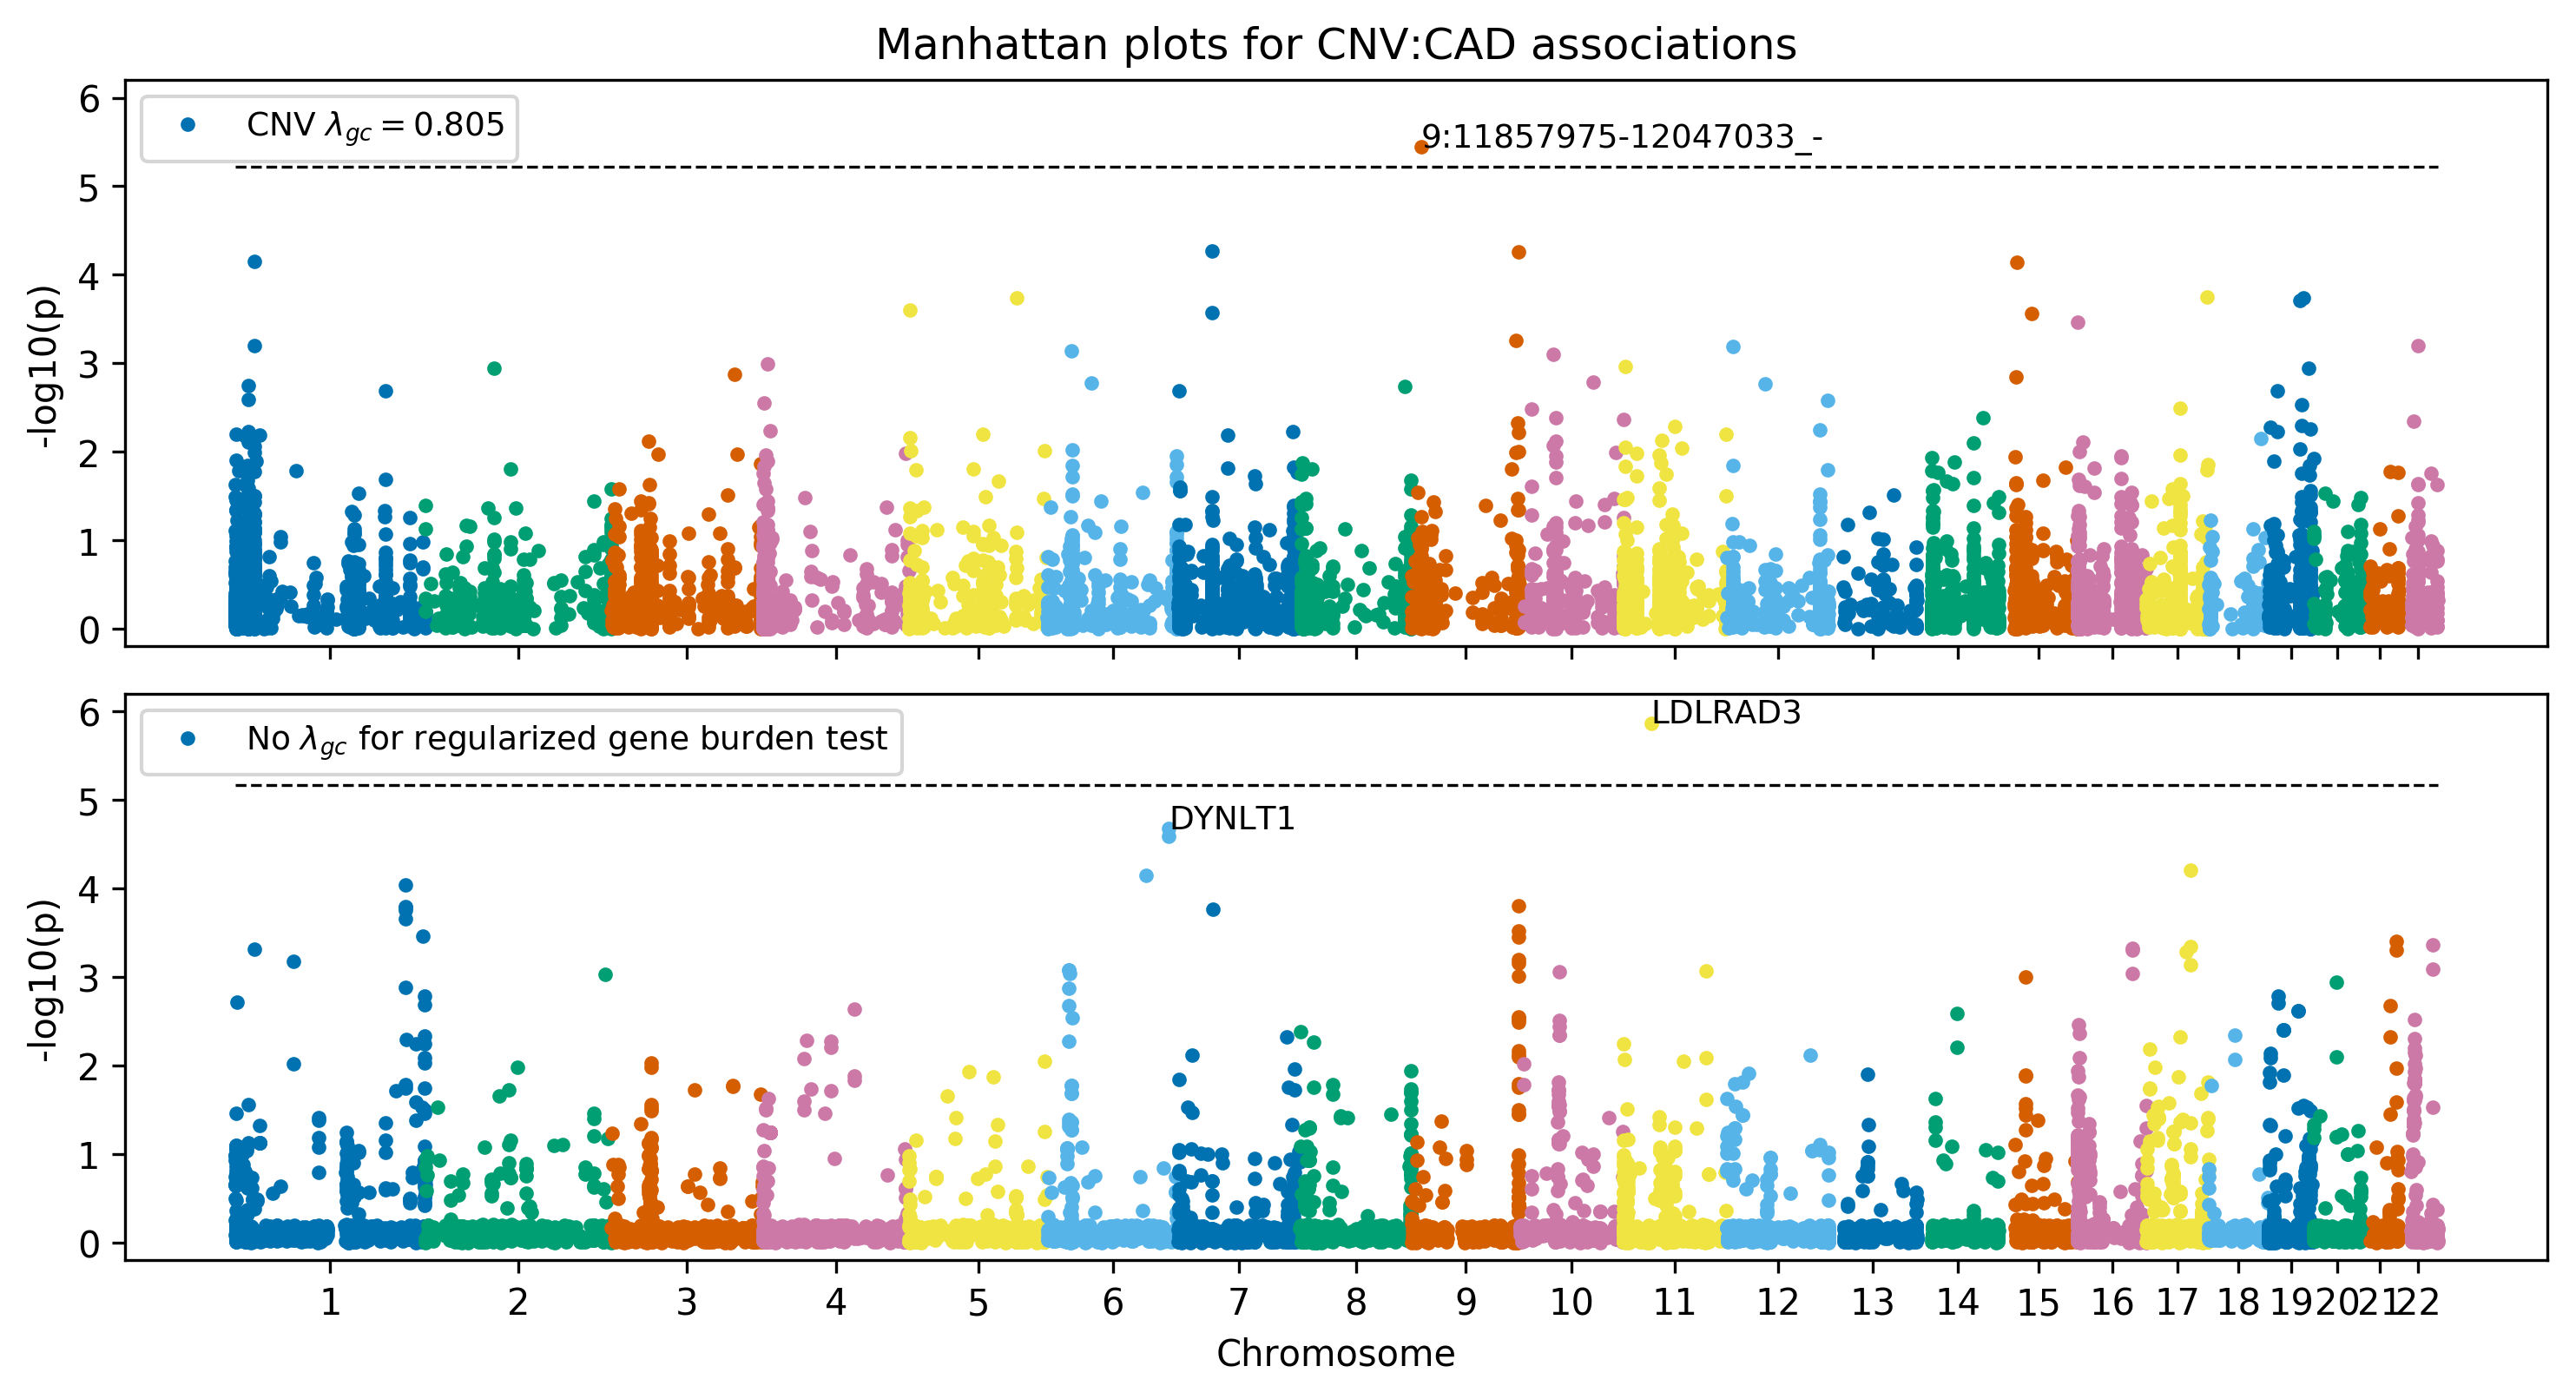

In [13]:
fig  = plt.figure(figsize=(12,6), dpi=300)
grid = plt.GridSpec(6,12,hspace=0.3)

# use this for manhattan plot
chrsize = {'1': 249250621,
           '2': 243199373,
           '3': 198022430,
           '4': 191154276,
           '5': 180915260,
           '6': 171115067,
           '7': 159138663,
           '23': 155270560, # X
           '8': 146364022,
           '9': 141213431,
           '10':135534747,
           '11':135006516,
           '12':133851895,
           '13':115169878,
           '14':107349540,
           '15':102531392,
           '16':90354753,
           '17':81195210,
           '18':78077248,
           '20':63025520,
           '24': 59373566, # Y
           '19':59128983,
           '22':51304566,
           '21':48129895}

#######################
# A: Traditional GWAS #
#######################
fig.add_subplot(grid[:3,:])

chrlentot = np.cumsum([0]+[chrsize[str(i)] for i in range(1,25) ])
chrbase = {str(c):chrlentot[i] for i,c in enumerate(list(range(1,23)) + ['X','Y'])}

# plot
gwas['X'] = gwas['CHR'].apply(lambda i: chrbase[str(i)]) + gwas['POS']
for c in range(1,23):
    plt.plot(gwas.loc[gwas['CHR'] == c, 'X'],
             gwas.loc[gwas['CHR'] == c, 'P'].apply(lambda x:-np.log10(x)), '.')

# add significance line
p_star = 0.05/gwas.shape[0]
mlp_star = -np.log10(p_star)
plt.plot([gwas['X'].min(), gwas['X'].max()], [mlp_star, mlp_star], 
         'k--', linewidth=0.8)

# annotate significant variants
for [n,x,p] in gwas[gwas['P'] < p_star].loc[:,['SNP','X','P']].values.tolist():
    plt.annotate(n, [x, -np.log10(p)], fontsize=9)

# labels
plt.title('Manhattan plots for CNV:CAD associations')
plt.xticks([chrlentot[c] + (chrlentot[c+1]-chrlentot[c])/2 for c in range(22)], ['' for _ in range(22)])
plt.legend([''.join(['CNV ', '$\lambda_{gc}=$', 
                    '{:.3f}'.format(np.median(1-chi2.ppf(gwas['P'].values, 1))/chi2.ppf(0.5,1))])],
           loc=2, fontsize=9)
plt.ylim((-0.2, 6.2))
plt.ylabel('-log10(p)')

##################
# B: Burden Test #
##################

fig.add_subplot(grid[3:,:])

# compute x-positions for plot
burden['X'] = burden['CHR'].apply(lambda i: chrbase[str(i)]) + burden['POS']

# plot the points
for c in range(1,23):
    plt.plot(burden.loc[burden['CHR'] == str(c), 'X'],
             burden.loc[burden['CHR'] == str(c), 'P'].apply(lambda x:-np.log10(x) if x < 0.99 else 0.2*np.random.random()), 
             '.')
    # add annotation for max point in each chromosome
    if burden.loc[burden['CHR'] == str(c), 'P'].min() < 10*p_star:
        info = burden.iloc[burden.loc[burden['CHR'] == str(c),'P'].idxmin(),:]
        plt.annotate(info['GENE'], [info['X'], -np.log10(info['P'])], fontsize=9)

# add significance line
p_star = 0.05/burden.shape[0]
mlp_star = -np.log10(p_star)
plt.plot([burden['X'].min(), burden['X'].max()], [mlp_star, mlp_star], 
         'k--', linewidth=0.8)
# labels
plt.xlabel('Chromosome')
plt.xticks([chrlentot[c] + (chrlentot[c+1]-chrlentot[c])/2 for c in range(22)], 
           [str(c+1) for c in range(22)])
plt.legend([' '.join(('No', '$\lambda_{gc}$', 'for regularized gene burden test'))],
           loc=2, fontsize=9)
plt.ylim((-0.2, 6.2))
plt.ylabel('-log10(p)')

##################
# C: QQ for GWAS #
##################
#ax = fig.add_subplot(grid[1:,13:])
#
#probplot(-np.log10(gwas['P'].values), dist=expon, plot=ax)
#plt.legend(['$\lambda_{gc}=$'+'{:.3f}'.format(np.median(1-chi2.ppf(gwas['P'].values, 1))/chi2.ppf(0.5,1)),
#            'Null distribution'])
#plt.title('QQ for CAD CNV GWAS')
#plt.ylabel('Observed -log10(p)')
#plt.xlabel('Expected -log10(p)')

plt.show()